Import bibliotek

In [8]:
# IMPORT BIBLIOTEK I MODELI

# =========================
# 1. Biblioteki ogólne
# =========================
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 2. Podział danych i walidacja
# =========================
from sklearn.model_selection import GroupKFold, cross_validate, RandomizedSearchCV, cross_val_predict

# =========================
# 3. Preprocessing i pipeline
# =========================
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# =========================
# 4. Modele klasyfikacyjne
# =========================
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# =========================
# 5. Metryki i wizualizacja
# =========================
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
)


Import danych

In [9]:
# IMPORT DANYCH

# =========================
# 1. Wczytanie danych
# =========================
df = pd.read_csv("data/new_data.csv")

# =========================
# 2. Przygotowanie zmiennych
# =========================
X = df.drop(columns=["Class", "ID"])
y = df["Class"]
y_num = (df["Class"] == "ADHD").astype(int)
groups = df["ID"]


Prawidłowy split

In [10]:
cv = GroupKFold(n_splits=5)

Do dalszej analizy wybrano kilka klasycznych modeli uczenia maszynowego, które dobrze sprawdzają się w problemach klasyfikacyjnych przy stosunkowo niewielkich zbiorach danych. W szczególności wybrane zostały modele, które w wielu zastosowaniach tabelarycznych osiągają lepsze wyniki niż proste sieci neuronowe.
 * Logistic Regression – model liniowy stanowiący punkt odniesienia (baseline) dla bardziej złożonych metod.
 * Support Vector Machine (SVM) – model wyznaczający hiperpłaszczyznę maksymalizującą margines między klasami, który dzięki zastosowaniu funkcji jądra (np. RBF) pozwala modelować również nieliniowe zależności w danych.
 * Random Forest – zespół wielu drzew decyzyjnych uczonych na losowych podzbiorach danych i cech, zdolny do modelowania bardziej złożonych zależności między zmiennymi, choć mniej interpretowalny niż modele liniowe.
 * XGBoost – metoda boostingowa oparta na drzewach decyzyjnych, w której kolejne modele uczą się na błędach poprzednich, co często prowadzi do bardzo dobrych wyników na danych tabelarycznych.
 * MLP - prosta sieć neuronowa

In [11]:
models = {

    "LogReg": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        # model ma 100 iteracji
        ("model", LogisticRegression(max_iter=100, random_state=123))

    ]),

    "SVM_RBF": Pipeline([

        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        # JĄDRO RBF pozwala na modelowanie zakrzywionych hiperpłaszczyzn a nie prostych
        # Na podstawie PCA z EDA można wnioskować, że to lepszy wybór
        ("model", SVC(kernel="rbf", random_state=123))

    ]),

    "RandomForest": Pipeline([

        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            # Model oparty na 367 drzewach 
            n_estimators=367,
            random_state=123
        ))

    ]),

    "XGBoost": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", XGBClassifier(
            # 367 drzew w modelu
            n_estimators=367,
            # maksymalna głębokość pojedynczego drzewa na 4
            max_depth=4,
            # lr
            learning_rate=0.05,
            # każde drzewo uczy się na 80% obserwacji, to działa jak regularyzacja
            subsample=0.8,
            # każde drzewo widzi tylko 80% cech, kolejny sposób na regularyzację
            colsample_bytree=0.8,
            # kara za zbyt duże/ agresywne dopasowanie
            reg_lambda=1.0,
            # mierzy jakość przewidywanych prawdopodobieństw
            eval_metric="logloss",

        ))
    ]),

    "MLP": Pipeline([

        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", MLPClassifier(
            hidden_layer_sizes=(32, 16),
            activation="relu",
            alpha=1e-3,
            learning_rate_init=1e-3,
            max_iter=2000,
            early_stopping=True,
            random_state=42
        ))
        
    ]),
}

## Benchmark bazowy

In [12]:
# =========================
# Porównanie modeli
# =========================
# Ocena modeli z użyciem GroupKFold oraz metryki accuracy.
# Dla każdego modelu zapisujemy średni wynik accuracy
# oraz odchylenie standardowe pomiędzy foldami.

results = []
scoring = ["accuracy"]

for name, pipe in models.items():
    scores = cross_validate(
        pipe,
        X,
        y_num,
        cv=cv,
        groups=groups,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    results.append({
        "model": name,
        "acc_mean": scores["test_accuracy"].mean(),
        "acc_std": scores["test_accuracy"].std()
    })

results_df = pd.DataFrame(results).sort_values("acc_mean", ascending = False)
print(results_df.round(3))

          model  acc_mean  acc_std
3       XGBoost     0.792    0.080
2  RandomForest     0.768    0.069
1       SVM_RBF     0.751    0.061
0        LogReg     0.743    0.069
4           MLP     0.496    0.033


Wstępny benchmark pokazuje wszystkie wyniki najlepsze dla XGBoost

Hyperparameter tuning dla tego klasyfikatora

In [13]:
# =========================
# Strojenie hiperparametrów modelu XGBoost
# =========================

# Pipeline: imputacja braków danych + klasyfikator XGBoost
pipe_xgb = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBClassifier(
        eval_metric="logloss",   # metryka używana wewnętrznie przez XGBoost
        random_state=42
    ))
])

# Zakres przeszukiwanych hiperparametrów modelu
param_grid = {
    "model__n_estimators": [100, 200, 300, 500, 600],   # liczba drzew
    "model__max_depth": [2, 3, 4, 5, 6],                # maksymalna głębokość drzewa
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.15],  # współczynnik uczenia
    "model__subsample": [0.6, 0.8, 1.0],                # udział obserwacji używanych przez drzewo
    "model__colsample_bytree": [0.5, 0.7, 0.8, 1.0],    # udział cech używanych przez drzewo
    "model__min_child_weight": [1, 2, 4, 6],            # minimalna "waga" liścia
    "model__reg_lambda": [0.5, 1.0, 2.0, 5.0],          # regularyzacja L2
}

# Losowe przeszukiwanie przestrzeni hiperparametrów
search = RandomizedSearchCV(
    estimator=pipe_xgb,
    param_distributions=param_grid,
    n_iter=40,            # liczba losowo testowanych kombinacji
    scoring="accuracy",   # kryterium wyboru najlepszego modelu
    cv=cv,                # walidacja krzyżowa zdefiniowana wcześniej
    n_jobs=-1,            # użycie wszystkich dostępnych rdzeni CPU
    refit=True,           # po wyborze najlepszych parametrów dopasuj model ponownie na całym zbiorze
    random_state=42
)

# Dopasowanie RandomizedSearchCV do danych
search.fit(X, y_num, groups=groups)

# Wyniki
print("Najlepsze parametry:", search.best_params_)
print("Best CV accuracy:", round(search.best_score_, 4))

Najlepsze parametry: {'model__subsample': 0.8, 'model__reg_lambda': 0.5, 'model__n_estimators': 600, 'model__min_child_weight': 1, 'model__max_depth': 5, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.5}
Best CV accuracy: 0.8007


Uważam, że biorąc pod uwagę niewielką liczebność zbioru danych (120 próbek), uzyskane accuracy na poziomie 81% można uznać za zadowalające.

Accuracy: 0.8017


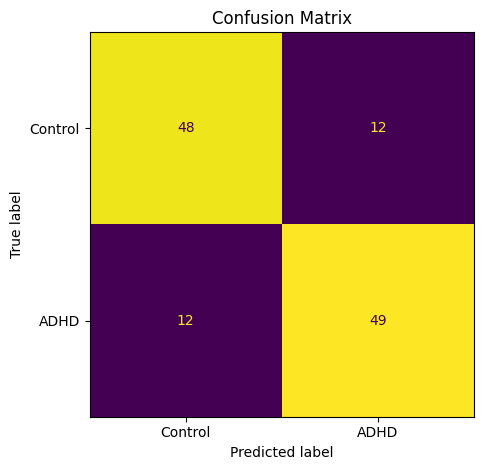

In [14]:
# =========================
# Ewaluacja najlepszego modelu
# =========================

# Najlepszy model wybrany w procesie strojenia hiperparametrów
best_model = search.best_estimator_

# Predykcje out-of-fold:
# każda obserwacja jest przewidywana przez model,
# który nie widział jej podczas treningu
y_pred = cross_val_predict(
    best_model,
    X,
    y_num,
    cv=cv,
    groups=groups,
    method="predict",
    n_jobs=-1
)

# Podstawowa metryka jakości
print("Accuracy:", round(accuracy_score(y_num, y_pred), 4))

# Macierz pomyłek
cm = confusion_matrix(y_num, y_pred)
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Control", "ADHD"]
).plot(colorbar=False)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

Analiza macierzy pomyłek wskazuje, że poziom błędnych predykcji w obu klasach kształtuje się na poziomie około 20%. Wynik ten można ocenić jako zadowalający, szczególnie w kontekście stosunkowo małej liczebności zbioru danych (120 próbek).

Najlepsze accuracy dla XGBoost, 81% uważam to za bardzo zadowalający wynik z uwagi na mały zbiór uczący jak i testowe (łącznie 121 obs)

W eksperymencie porównano pięć klasyfikatorów: regresję logistyczną, maszynę wektorów nośnych z jądrem RBF, Random Forest, XGBoost oraz wielowarstwowy perceptron (MLP). Regresja logistyczna stanowi model liniowy, SVM umożliwia nieliniową separację klas, Random Forest i XGBoost reprezentują podejście oparte na zespołach drzew decyzyjnych, natomiast MLP jest prostą siecią neuronową zdolną do modelowania bardziej złożonych zależności. Dla modeli wrażliwych na skalę cech zastosowano standaryzację, a we wszystkich przypadkach braki danych uzupełniono medianą.

W trakcie pracy korzystałem pomocniczo z narzędzi AI głównie przy porządkowaniu kodu, poprawie jego czytelności oraz doprecyzowaniu części komentarzy i opisów. Dobór modeli klasyfikacyjnych, decyzje analityczne, wstępna selekcja wskaźników na etapie EDA oraz końcowa redakcja rozwiązania były jednak moją samodzielną pracą. AI pełniło rolę wsparcia technicznego i edytorskiego, a nie autora całego rozwiązania.